In [1]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [6]:
#@title Plotting Settings
def plot_cur_mem_spk(cur, mem, spk, thr_line=False, vline=False, title=False, ylim_max1=1.25, ylim_max2=1.25):
    # Generate Plots
    fig, ax = plt.subplots(3, figsize=(8,6), sharex=True, 
                            gridspec_kw = {'height_ratios': [1, 1, 0.4]})

    # Plot input current
    ax[0].plot(cur, c="tab:orange")
    ax[0].set_ylim([0, ylim_max1])
    ax[0].set_xlim([0, 200])
    ax[0].set_ylabel("Input Current ($I_{in}$)")
    if title:
        ax[0].set_title(title)

    # Plot membrane potential
    ax[1].plot(mem)
    ax[1].set_ylim([0, ylim_max2]) 
    ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")
    if thr_line:
        ax[1].axhline(y=thr_line, alpha=0.25, linestyle="dashed", c="black", linewidth=2)
    plt.xlabel("Time step")

    # Plot output spike using spikeplot
    splt.raster(spk, ax[2], s=400, c="black", marker="|")
    if vline:
        ax[2].axvline(x=vline, ymin=0, ymax=6.75, alpha = 0.15, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
    plt.ylabel("Output spikes")
    plt.yticks([]) 

    plt.show()

def plot_snn_spikes(spk_in, spk1_rec, spk2_rec, title):
    # Generate Plots
    fig, ax = plt.subplots(3, figsize=(8,7), sharex=True, 
                            gridspec_kw = {'height_ratios': [1, 1, 0.4]})

    # Plot input spikes
    splt.raster(spk_in[:,0], ax[0], s=0.03, c="black")
    ax[0].set_ylabel("Input Spikes")
    ax[0].set_title(title)

    # Plot hidden layer spikes
    splt.raster(spk1_rec.reshape(num_steps, -1), ax[1], s = 0.05, c="black")
    ax[1].set_ylabel("Hidden Layer")

    # Plot output spikes
    splt.raster(spk2_rec.reshape(num_steps, -1), ax[2], c="black", marker="|")
    ax[2].set_ylabel("Output Spikes")
    ax[2].set_ylim([0, 10])

    plt.show()

In [5]:
num_steps = 200

In [2]:
# Init network
num_inputs = 784
num_hidden = 1000
num_outputs = 10
beta = 0.99

fc1 = nn.Linear(num_inputs, num_hidden)
lif1 = snn.Leaky(beta=beta)
fc2 = nn.Linear(num_hidden, num_outputs)
lif2 = snn.Leaky(beta=beta)

In [3]:
# Hidden states
mem1 = lif1.init_leaky()
mem2 = lif2.init_leaky()

mem2_rec = []
spk1_rec = []
spk2_rec = []

In [4]:
# Input data
spk_in = spikegen.rate_conv(torch.rand((200, 784))).unsqueeze(1)
print(f"Dimensions of spk_in: {spk_in.size()}")

Dimensions of spk_in: torch.Size([200, 1, 784])


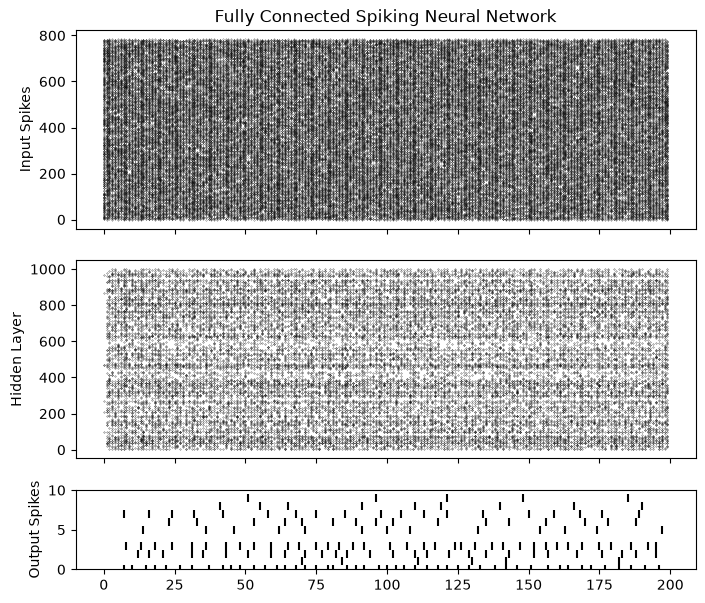

In [7]:
# Simulate network
for step in range(num_steps):
    cur1 = fc1(spk_in[step])
    spk1, mem1 = lif1(cur1, mem1)
    cur2 = fc2(spk1)
    spk2, mem2 = lif2(cur2, mem2)

    mem2_rec.append(mem2)
    spk1_rec.append(spk1)
    spk2_rec.append(spk2)

mem2_rec = torch.stack(mem2_rec)
spk1_rec = torch.stack(spk1_rec)
spk2_rec = torch.stack(spk2_rec)

plot_snn_spikes(spk_in, spk1_rec, spk2_rec, "Fully Connected Spiking Neural Network")

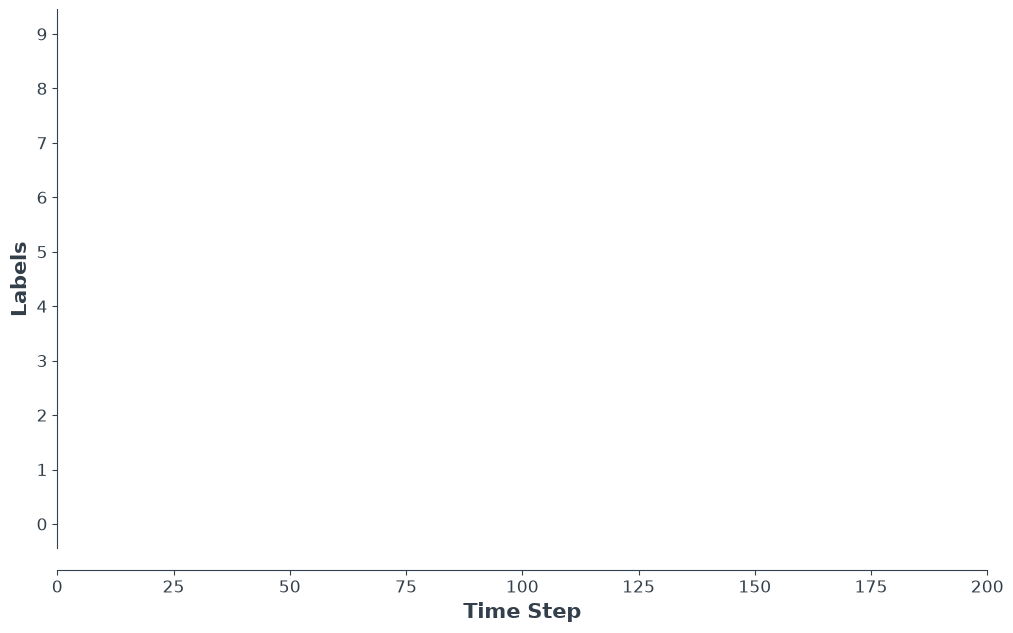

In [14]:
from IPython.display import HTML
import imageio_ffmpeg

fig, ax = plt.subplots(facecolor="w", figsize=(12, 7))
labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
spk2_rec = spk2_rec.squeeze(1).detach().cpu()

plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
anim = splt.spike_count(spk2_rec, fig, ax, labels=labels, animate=True)
HTML(anim.to_html5_video())

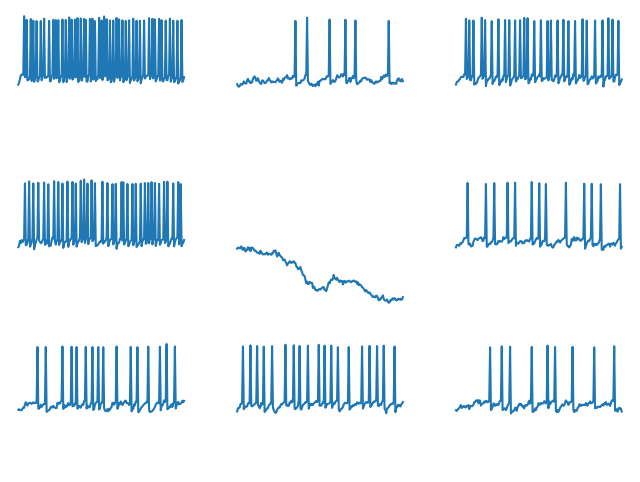

In [15]:
splt.traces(mem2_rec.squeeze(1), spk=spk2_rec.squeeze(1))
fig = plt.gcf()
fig.set_size_inches(8, 6)

In [16]:
alpha = 0.9
beta = 0.8
num_steps = 200

lif1 = snn.Synaptic(alpha=alpha, beta=beta)